## 1. l2 regularization

In [24]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()



In [25]:
class RunnerM_l2:
    def __init__(self, model, optimizer, metric, loss_fn, batch_size=32, scheduler=None, augmentation_config=None):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metric = metric
        self.scheduler = scheduler
        self.batch_size = batch_size
        self.train_scores = []
        self.dev_scores = []
        self.train_loss = []
        self.dev_loss = []
        self.l2_loss_history = []  # 添加 L2 损失历史
        # Initialize data augmenter if config is provided
        if augmentation_config and augmentation_config.get("if_use_augment", False):
            model_type = getattr(model, 'model_type', 
                               "CNN" if hasattr(model, 'conv_layer_config') else "MLP")
            self.augmenter = mynn.runner.DataAugmentation(**augmentation_config, mode=model_type)

            print(f"Using data augmentation. The settings:")
            for key, val in augmentation_config.items():
                if key != "if_use_augment":
                    print(f"  {key}: {val}")
        else:
            self.augmenter = None
            
    def train(self, train_set, dev_set, **kwargs):
        num_epochs = kwargs.get("num_epochs", 0)
        log_iters = kwargs.get("log_iters", 100)
        save_dir = kwargs.get("save_dir", "best_model")
        early_stop = kwargs.get("early_stop", 10)

        if not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)

        iteration_in_epoch = (train_set[0].shape[0] + self.batch_size - 1) // self.batch_size
        early_stop = early_stop * iteration_in_epoch
        best_score = 0
        flag = 0
        iteration_counter = 0  # Global iteration counter

        for epoch in range(num_epochs):
            X, y = train_set
            assert X.shape[0] == y.shape[0]
            idx = np.random.permutation(X.shape[0])
            X, y = X[idx], y[idx]

            iteration_in_epoch = (X.shape[0] + self.batch_size - 1) // self.batch_size
            n = X.shape[0]

            for iteration in range(iteration_in_epoch):
                start = iteration * self.batch_size
                end = min(start + self.batch_size, n)

                train_X = X[start:end]
                train_y = y[start:end]

                if self.augmenter is not None:
                    train_X = self.augmenter.augment(train_X)

                logits = self.model(train_X)
                trn_loss = self.loss_fn(logits, train_y)

                # Add L2 regularization loss
                l2_loss = self.model.get_l2_loss()  # Calculate L2 loss
                trn_loss += l2_loss  # Add L2 loss to the total loss

                trn_score = self.metric(logits, train_y)

                self.loss_fn.backward()
                self.optimizer.step()
                if self.scheduler is not None:
                    self.scheduler.step()

                self.train_loss.append(trn_loss)
                self.train_scores.append(trn_score)
                self.l2_loss_history.append(l2_loss)  # 记录 L2 损失

                dev_score, dev_loss = self.evaluate(dev_set)
                self.dev_scores.append(dev_score)
                self.dev_loss.append(dev_loss)
                iteration_counter += 1

                if iteration_counter % log_iters == 0:
                    print(f"[Iter {iteration_counter}]")
                    print(f"[Train] loss: {trn_loss:.5f}, score: {trn_score:.5f}")
                    print(f"[Dev] loss: {dev_loss:.5f}, score: {dev_score:.5f}")

                    if dev_score > best_score:
                        flag = 0
                    else:
                        flag += 1
                        if flag > early_stop:
                            print(f"Early stopping at iteration {iteration_counter} with best score {best_score:.5f}")
                            self.best_score = best_score
                            return

            if dev_score > best_score:
                save_path = os.path.join(save_dir, 'best_model.pickle')
                self.save_model(save_path)
                print(f"Best accuracy updated: {best_score:.5f} --> {dev_score:.5f}")
                best_score = dev_score

        self.best_score = best_score
        
    def evaluate(self, data_set):
        X, y = data_set
        logits = self.model(X)
        loss = self.loss_fn(logits, y)
        score = self.metric(logits, y)
        return score, loss
    
    def save_model(self, save_path):
        self.model.save_model(save_path)



In [26]:
def train_model(nHidden=[128], lr=1.0, epochs=3, early_stop=3, initialize_method='He', lambda1=0.0001):
    size_list = [train_imgs.shape[1]] + nHidden + [10]
    lambda_list = [lambda1] * (len(nHidden) + 1)  # 每层一个lambda
    
    # 初始化模型
    model = mynn.models.Model_MLP(size_list, 'ReLU', lambda_list, dropout_p=None, initialize_method=initialize_method)
    my_optimizer = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)
    scheduler = mynn.lr_scheduler.MultiStepLR(my_optimizer, milestones=[500, 1500, 2500, 3000], gamma=0.5)
    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    
    # 使用修改后的 RunnerM_l2 类进行训练
    trainer = RunnerM_l2(model=model, optimizer=my_optimizer, metric=mynn.metric.accuracy, loss_fn=loss_fn, batch_size=32, scheduler=scheduler)
    
    trainer.train(
        train_set=[train_imgs, train_labs],
        dev_set=[valid_imgs, valid_labs],
        num_epochs=epochs,
        log_iters=100,
        early_stop=early_stop,
        save_dir = f'./saved_models/Q3/{lambda1}_lambda'
    )
    
    _, axes = plt.subplots(1, 3, figsize=(18, 4))  # 创建三个子图

    # 绘制训练和验证损失曲线
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Iters')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # 绘制训练和验证准确度曲线
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Iters')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    # 绘制L2损失曲线
    axes[2].plot(trainer.l2_loss_history, label='L2 Loss', color='orange')
    axes[2].set_title('L2 Loss Curve')
    axes[2].set_xlabel('Iters')
    axes[2].set_ylabel('L2 Loss')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return trainer


### $\lambda = 1.0$

[Iter 100]
[Train] loss: 2.30166, score: 0.09375
[Dev] loss: 2.30262, score: 0.09370
[Iter 200]
[Train] loss: 2.30340, score: 0.12500
[Dev] loss: 2.30251, score: 0.10080
[Iter 300]
[Train] loss: 2.30211, score: 0.06250
[Dev] loss: 2.30248, score: 0.09970
[Iter 400]
[Train] loss: 2.30182, score: 0.09375
[Dev] loss: 2.30266, score: 0.09370
[Iter 500]
[Train] loss: 2.30096, score: 0.21875
[Dev] loss: 2.30236, score: 0.11720
[Iter 600]
[Train] loss: 2.30251, score: 0.12500
[Dev] loss: 2.30254, score: 0.10080
[Iter 700]
[Train] loss: 2.30244, score: 0.18750
[Dev] loss: 2.30253, score: 0.10040
[Iter 800]
[Train] loss: 2.30180, score: 0.06250
[Dev] loss: 2.30253, score: 0.11720
[Iter 900]
[Train] loss: 2.30259, score: 0.12500
[Dev] loss: 2.30264, score: 0.09650
[Iter 1000]
[Train] loss: 2.30247, score: 0.15625
[Dev] loss: 2.30256, score: 0.10040
[Iter 1100]
[Train] loss: 2.30159, score: 0.21875
[Dev] loss: 2.30255, score: 0.10080
[Iter 1200]
[Train] loss: 2.30245, score: 0.03125
[Dev] loss: 2

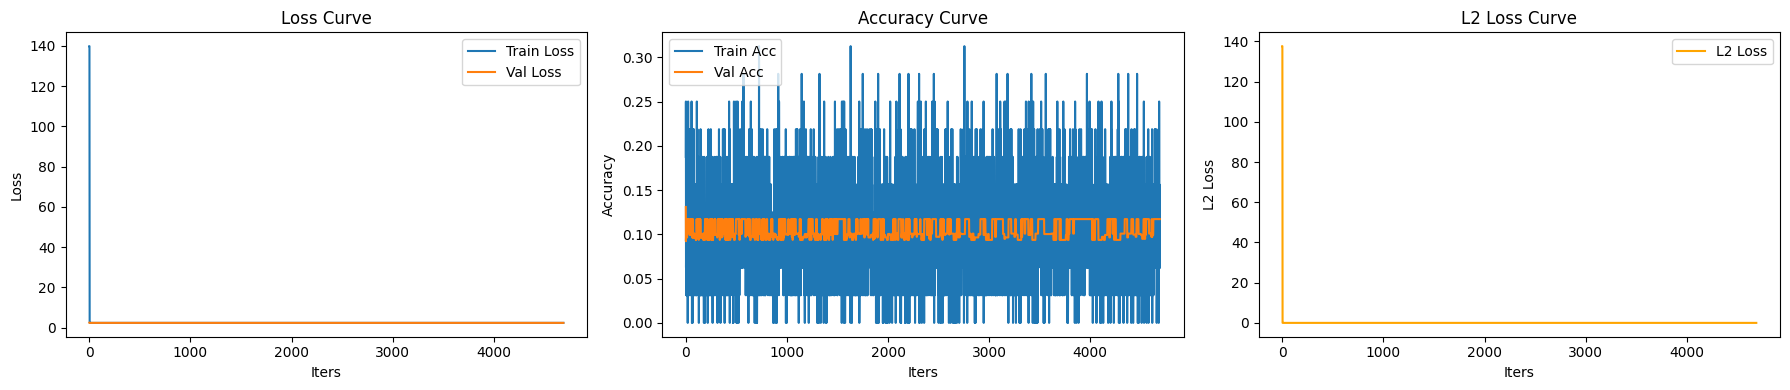

Best train set accuracy: 0.3125
Best validation set accuracy: 0.1172


In [27]:
train0 = train_model(lambda1=1.0)
print("Best train set accuracy:", max(train0.train_scores))
print("Best validation set accuracy:", train0.best_score)

### $\lambda = 0.0$

[Iter 100]
[Train] loss: 0.44495, score: 0.81250
[Dev] loss: 0.46317, score: 0.85970
[Iter 200]
[Train] loss: 0.55889, score: 0.81250
[Dev] loss: 0.38187, score: 0.88160
[Iter 300]
[Train] loss: 0.51674, score: 0.93750
[Dev] loss: 0.31493, score: 0.90570
[Iter 400]
[Train] loss: 0.21937, score: 0.93750
[Dev] loss: 0.31563, score: 0.90250
[Iter 500]
[Train] loss: 0.09454, score: 1.00000
[Dev] loss: 0.22683, score: 0.93260
[Iter 600]
[Train] loss: 0.62107, score: 0.84375
[Dev] loss: 0.19929, score: 0.94330
[Iter 700]
[Train] loss: 0.09922, score: 0.96875
[Dev] loss: 0.18662, score: 0.94450
[Iter 800]
[Train] loss: 0.17597, score: 0.96875
[Dev] loss: 0.19008, score: 0.94340
[Iter 900]
[Train] loss: 0.09410, score: 0.96875
[Dev] loss: 0.17125, score: 0.94980
[Iter 1000]
[Train] loss: 0.38906, score: 0.93750
[Dev] loss: 0.17505, score: 0.94940
[Iter 1100]
[Train] loss: 0.08623, score: 0.96875
[Dev] loss: 0.16116, score: 0.95290
[Iter 1200]
[Train] loss: 0.17000, score: 0.93750
[Dev] loss: 0

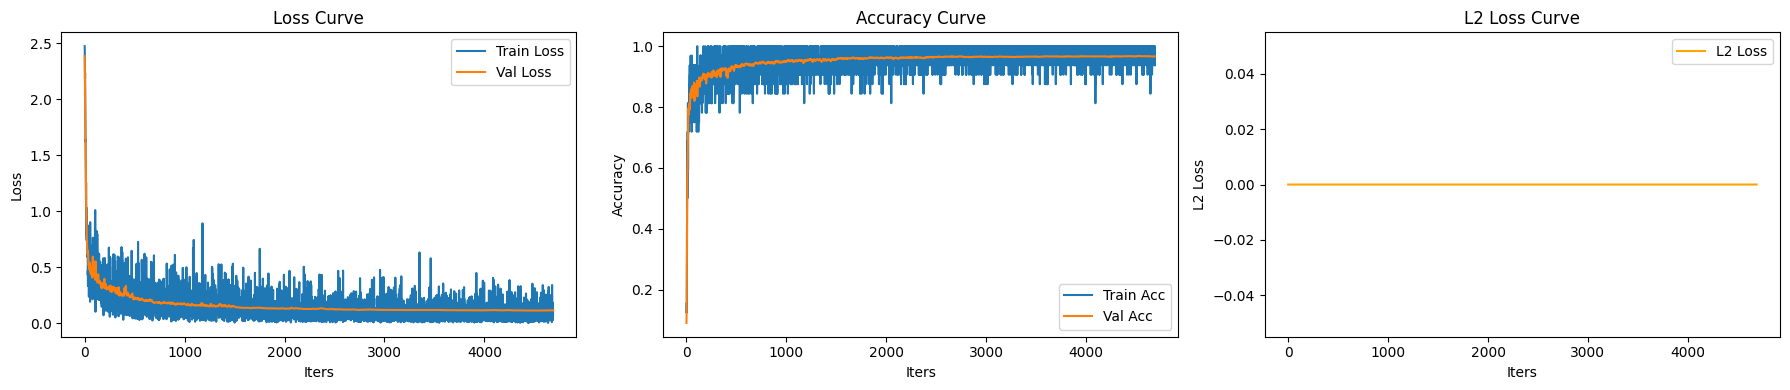

Best train set accuracy: 1.0
Best validation set accuracy: 0.9665


In [28]:
train1 = train_model(lambda1=0.0)
print("Best train set accuracy:", max(train1.train_scores))
print("Best validation set accuracy:", train1.best_score)

### $\lambda = 0.1$

[Iter 100]
[Train] loss: 2.29927, score: 0.15625
[Dev] loss: 2.30207, score: 0.11720
[Iter 200]
[Train] loss: 2.29144, score: 0.15625
[Dev] loss: 2.30205, score: 0.11720
[Iter 300]
[Train] loss: 2.30272, score: 0.06250
[Dev] loss: 2.30267, score: 0.09930
[Iter 400]
[Train] loss: 2.30259, score: 0.12500
[Dev] loss: 2.30235, score: 0.10030
[Iter 500]
[Train] loss: 2.29943, score: 0.00000
[Dev] loss: 2.30191, score: 0.09930
[Iter 600]
[Train] loss: 2.30421, score: 0.03125
[Dev] loss: 2.30295, score: 0.09370
[Iter 700]
[Train] loss: 2.30138, score: 0.09375
[Dev] loss: 2.30213, score: 0.11720
[Iter 800]
[Train] loss: 2.30591, score: 0.09375
[Dev] loss: 2.30229, score: 0.09720
[Iter 900]
[Train] loss: 2.29603, score: 0.18750
[Dev] loss: 2.30251, score: 0.10040
[Iter 1000]
[Train] loss: 2.30638, score: 0.06250
[Dev] loss: 2.30224, score: 0.11720
[Iter 1100]
[Train] loss: 2.29624, score: 0.12500
[Dev] loss: 2.30234, score: 0.10040
[Iter 1200]
[Train] loss: 2.30729, score: 0.12500
[Dev] loss: 2

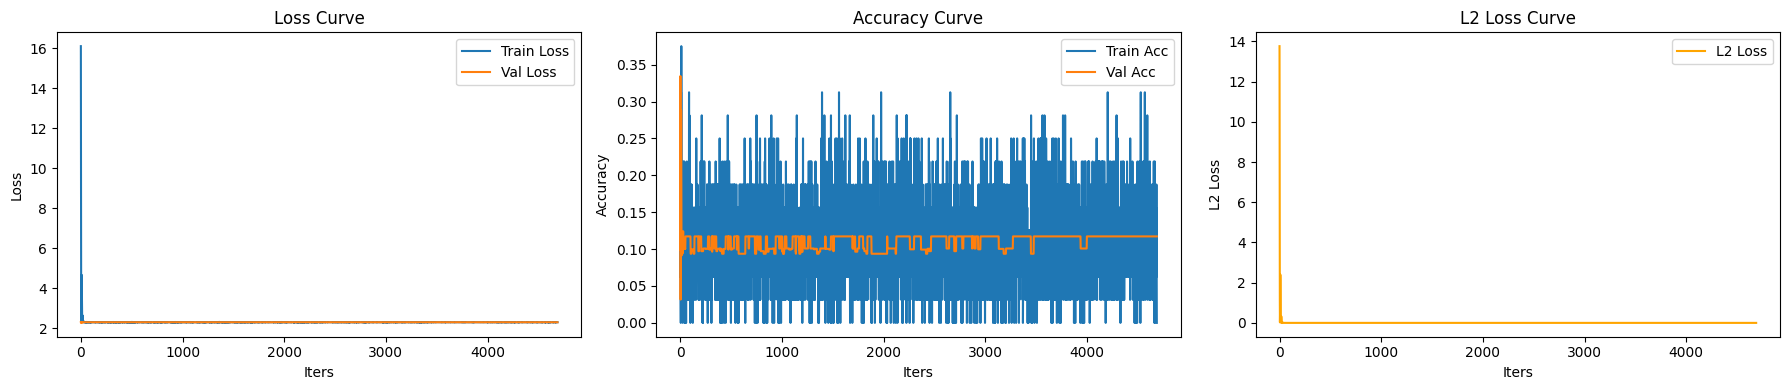

Best train set accuracy: 0.375
Best validation set accuracy: 0.1172


In [29]:
train1_5 = train_model(lambda1=0.1)
print("Best train set accuracy:", max(train1_5.train_scores))
print("Best validation set accuracy:", train1_5.best_score)

### $\lambda = 0.01$

[Iter 100]
[Train] loss: 2.01490, score: 0.53125
[Dev] loss: 1.96719, score: 0.49580
[Iter 200]
[Train] loss: 1.90210, score: 0.68750
[Dev] loss: 1.94528, score: 0.43740
[Iter 300]
[Train] loss: 1.94118, score: 0.43750
[Dev] loss: 1.93886, score: 0.45730
[Iter 400]
[Train] loss: 1.96684, score: 0.40625
[Dev] loss: 1.98642, score: 0.46890
[Iter 500]
[Train] loss: 1.99533, score: 0.28125
[Dev] loss: 1.92314, score: 0.36720
[Iter 600]
[Train] loss: 1.96782, score: 0.46875
[Dev] loss: 1.94517, score: 0.49420
[Iter 700]
[Train] loss: 1.85730, score: 0.59375
[Dev] loss: 1.93540, score: 0.45270
[Iter 800]
[Train] loss: 1.95946, score: 0.46875
[Dev] loss: 1.92285, score: 0.49390
[Iter 900]
[Train] loss: 2.00024, score: 0.34375
[Dev] loss: 1.93624, score: 0.43420
[Iter 1000]
[Train] loss: 2.00426, score: 0.37500
[Dev] loss: 1.92683, score: 0.48680
[Iter 1100]
[Train] loss: 1.92204, score: 0.46875
[Dev] loss: 1.91349, score: 0.51520
[Iter 1200]
[Train] loss: 1.93052, score: 0.59375
[Dev] loss: 1

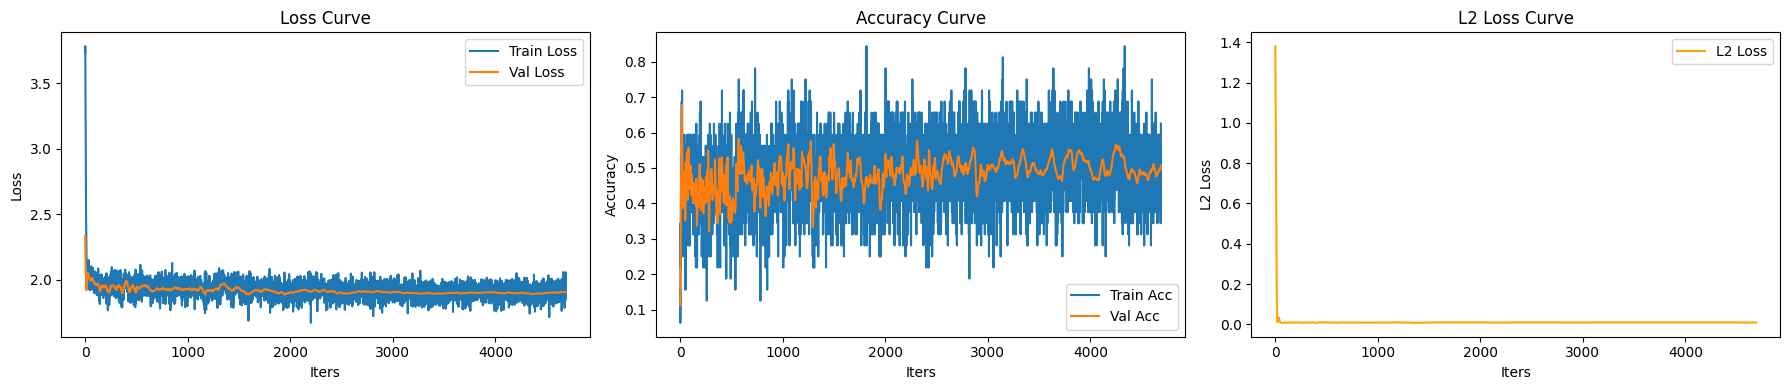

Best train set accuracy: 0.84375
Best validation set accuracy: 0.5287


In [30]:
train2 = train_model(lambda1=0.01)
print("Best train set accuracy:", max(train2.train_scores))
print("Best validation set accuracy:", train2.best_score)

### $\lambda = 1e-3$

[Iter 100]
[Train] loss: 0.50911, score: 0.84375
[Dev] loss: 0.54957, score: 0.86630
[Iter 200]
[Train] loss: 0.69028, score: 0.81250
[Dev] loss: 0.53956, score: 0.86510
[Iter 300]
[Train] loss: 0.38198, score: 0.90625
[Dev] loss: 0.53874, score: 0.86240
[Iter 400]
[Train] loss: 0.65149, score: 0.78125
[Dev] loss: 0.53407, score: 0.87030
[Iter 500]
[Train] loss: 0.42660, score: 0.90625
[Dev] loss: 0.56058, score: 0.85020
[Iter 600]
[Train] loss: 0.54245, score: 0.84375
[Dev] loss: 0.52568, score: 0.87610
[Iter 700]
[Train] loss: 0.54784, score: 0.90625
[Dev] loss: 0.50444, score: 0.88280
[Iter 800]
[Train] loss: 0.63402, score: 0.81250
[Dev] loss: 0.51053, score: 0.87240
[Iter 900]
[Train] loss: 0.64324, score: 0.81250
[Dev] loss: 0.50642, score: 0.88080
[Iter 1000]
[Train] loss: 0.74644, score: 0.78125
[Dev] loss: 0.50301, score: 0.88240
[Iter 1100]
[Train] loss: 0.60832, score: 0.78125
[Dev] loss: 0.50880, score: 0.87720
[Iter 1200]
[Train] loss: 0.54270, score: 0.87500
[Dev] loss: 0

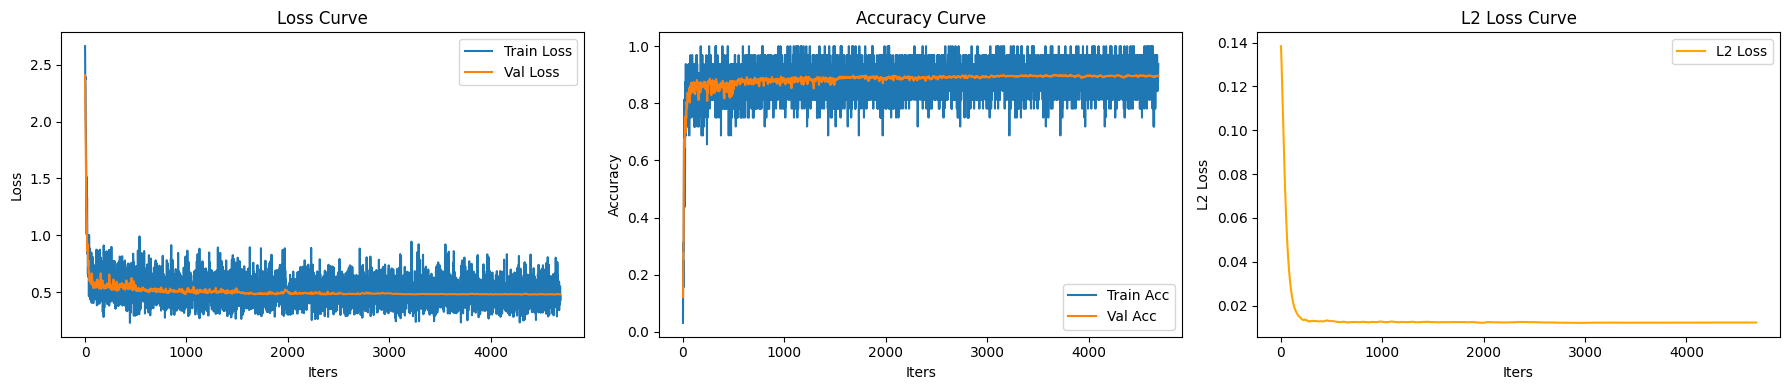

Best train set accuracy: 1.0
Best validation set accuracy: 0.8959


In [32]:
train3 = train_model(lambda1=1e-3)
print("Best train set accuracy:", max(train3.train_scores))
print("Best validation set accuracy:", train3.best_score)

### $\lambda = 1e-4$

[Iter 100]
[Train] loss: 0.52029, score: 0.84375
[Dev] loss: 0.43325, score: 0.86670
[Iter 200]
[Train] loss: 0.26414, score: 0.96875
[Dev] loss: 0.36789, score: 0.88530
[Iter 300]
[Train] loss: 0.23479, score: 0.96875
[Dev] loss: 0.30903, score: 0.91300
[Iter 400]
[Train] loss: 0.61207, score: 0.81250
[Dev] loss: 0.28867, score: 0.92030
[Iter 500]
[Train] loss: 0.18479, score: 0.96875
[Dev] loss: 0.26240, score: 0.92390
[Iter 600]
[Train] loss: 0.37361, score: 0.87500
[Dev] loss: 0.24015, score: 0.93350
[Iter 700]
[Train] loss: 0.12820, score: 0.96875
[Dev] loss: 0.24020, score: 0.93130
[Iter 800]
[Train] loss: 0.06020, score: 1.00000
[Dev] loss: 0.22837, score: 0.93650
[Iter 900]
[Train] loss: 0.27418, score: 0.93750
[Dev] loss: 0.22240, score: 0.93750
[Iter 1000]
[Train] loss: 0.12775, score: 0.93750
[Dev] loss: 0.22281, score: 0.93910
[Iter 1100]
[Train] loss: 0.23579, score: 0.93750
[Dev] loss: 0.21461, score: 0.93980
[Iter 1200]
[Train] loss: 0.17969, score: 0.96875
[Dev] loss: 0

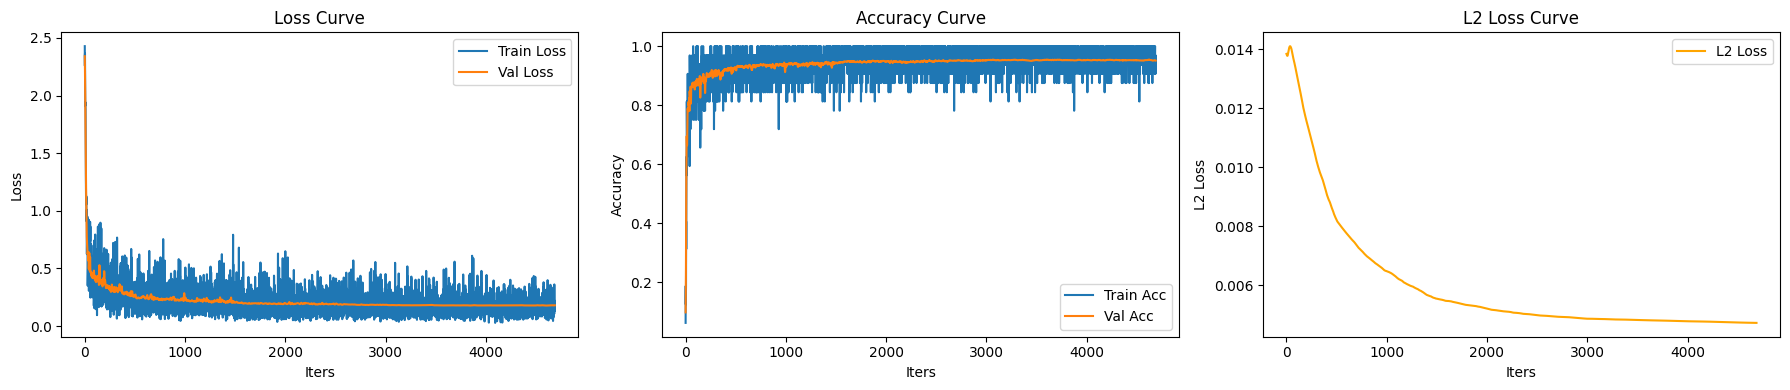

Best train set accuracy: 1.0
Best validation set accuracy: 0.9518


In [33]:
train4 = train_model(lambda1=1e-4)
print("Best train set accuracy:", max(train4.train_scores))
print("Best validation set accuracy:", train4.best_score)

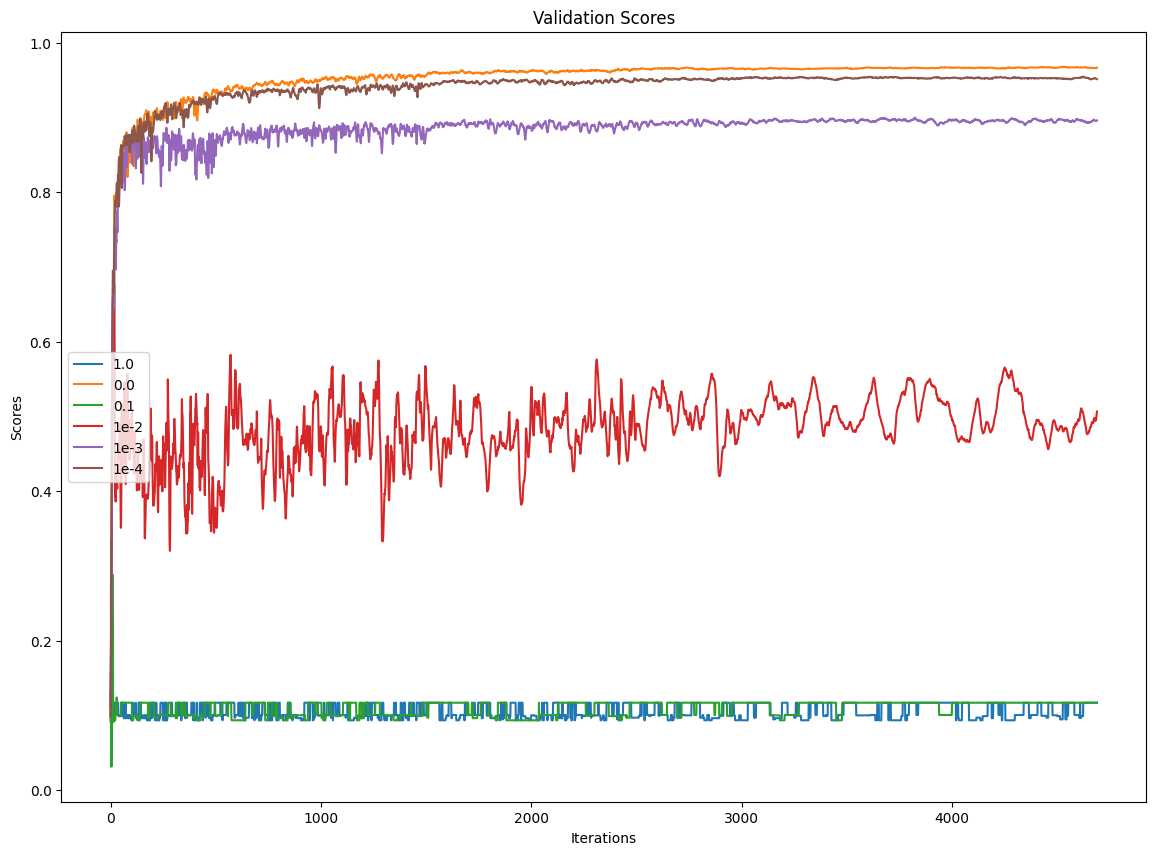

In [35]:
# # 绘制validation scores图像
plt.figure(figsize=(14, 10))
plt.plot(train0.dev_scores, label='1.0')
plt.plot(train1.dev_scores, label='0.0')
plt.plot(train1_5.dev_scores, label='0.1')
plt.plot(train2.dev_scores, label='1e-2')
plt.plot(train3.dev_scores, label='1e-3')
plt.plot(train4.dev_scores, label='1e-4')
plt.title('Validation Scores')
plt.xlabel('Iterations')
plt.ylabel('Scores')
plt.legend()

## 2. dropout

In [1]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()



In [3]:
def train_model(nHidden = [128], lr=1.0, epochs=3,early_stop=3, initialize_method='He',dropout_p=[0.5]):
    # 模型结构：输入层 + 隐藏层 + 输出层
    size_list = [train_imgs.shape[1]] + nHidden + [10]
    lambda_list = [1e-4] * (len(nHidden) + 1)  # 每层一个lambda
    
    # 初始化组件
    model = mynn.models.Model_MLP(size_list, 'ReLU', lambda_list, dropout_p=dropout_p, initialize_method=initialize_method)
    my_optimizer = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)

    scheduler = mynn.lr_scheduler.MultiStepLR(my_optimizer, milestones=[500, 1500, 2500, 3000], gamma=0.5)

    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    
    
    # 训练运行器
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=my_optimizer,
        metric=mynn.metric.accuracy,
        loss_fn=loss_fn,
        batch_size=32,
        scheduler=scheduler
    )
    
    # 执行训练
    trainer.train(
        train_set=[train_imgs, train_labs],
        dev_set=[valid_imgs, valid_labs],
        num_epochs=epochs,
        log_iters=200,
        early_stop = early_stop,
        save_dir = f'./saved_models/Q3/dropout_P{dropout_p}'
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 绘制训练和验证损失曲线
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Iters')  # x轴标签
    axes[0].set_ylabel('Loss')    # y轴标签
    axes[0].legend()

    # 绘制训练和验证准确度曲线
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Iters')  # x轴标签
    axes[1].set_ylabel('Accuracy')  # y轴标签
    axes[1].legend()

    plt.tight_layout()  # 自动调整布局
    plt.show()
    
    return trainer

### dropout_p=[0.5], $\lambda = 1e-4$

[Iter 200]
[Train] loss: 0.41179, score: 0.87500
[Dev] loss: 0.36658, score: 0.89370
[Iter 400]
[Train] loss: 0.30133, score: 0.90625
[Dev] loss: 0.30972, score: 0.90490
[Iter 600]
[Train] loss: 0.27344, score: 0.93750
[Dev] loss: 0.26337, score: 0.92930
[Iter 800]
[Train] loss: 0.28501, score: 0.90625
[Dev] loss: 0.23808, score: 0.93180
[Iter 1000]
[Train] loss: 0.41437, score: 0.84375
[Dev] loss: 0.23313, score: 0.93330
[Iter 1200]
[Train] loss: 0.20389, score: 0.96875
[Dev] loss: 0.23622, score: 0.93140
[Iter 1400]
[Train] loss: 0.24987, score: 0.93750
[Dev] loss: 0.23052, score: 0.93530
best accuracy updated: 0.00000 --> 0.94010
[Iter 1600]
[Train] loss: 0.15057, score: 0.93750
[Dev] loss: 0.21657, score: 0.93910
[Iter 1800]
[Train] loss: 0.26891, score: 0.93750
[Dev] loss: 0.21258, score: 0.94050
[Iter 2000]
[Train] loss: 0.23162, score: 0.90625
[Dev] loss: 0.20731, score: 0.94320
[Iter 2200]
[Train] loss: 0.29642, score: 0.90625
[Dev] loss: 0.20423, score: 0.94550
[Iter 2400]
[Tr

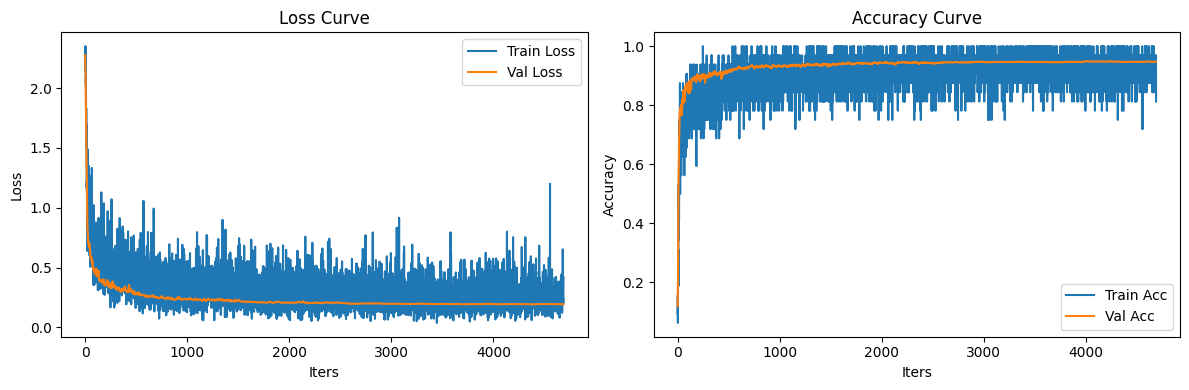

Best train set accuracy: 1.0
Best validation set accuracy: 0.9475


In [4]:
train5 = train_model(dropout_p=[0.5])
print("Best train set accuracy:", max(train5.train_scores))
print("Best validation set accuracy:", train5.best_score)

### dropout_p=[1.0], $\lambda = 1e-4$

[Iter 200]
[Train] loss: 0.17825, score: 0.93750
[Dev] loss: 0.37829, score: 0.88590
[Iter 400]
[Train] loss: 0.33161, score: 0.87500
[Dev] loss: 0.30626, score: 0.90640
[Iter 600]
[Train] loss: 0.09750, score: 0.96875
[Dev] loss: 0.23540, score: 0.93350
[Iter 800]
[Train] loss: 0.15977, score: 0.96875
[Dev] loss: 0.21728, score: 0.94130
[Iter 1000]
[Train] loss: 0.38569, score: 0.87500
[Dev] loss: 0.25784, score: 0.92630
[Iter 1200]
[Train] loss: 0.29158, score: 0.87500
[Dev] loss: 0.20957, score: 0.94500
[Iter 1400]
[Train] loss: 0.15225, score: 0.93750
[Dev] loss: 0.20410, score: 0.94310
best accuracy updated: 0.00000 --> 0.94930
[Iter 1600]
[Train] loss: 0.17139, score: 0.93750
[Dev] loss: 0.19312, score: 0.94840
[Iter 1800]
[Train] loss: 0.34592, score: 0.84375
[Dev] loss: 0.18980, score: 0.95000
[Iter 2000]
[Train] loss: 0.08648, score: 1.00000
[Dev] loss: 0.18420, score: 0.95240
[Iter 2200]
[Train] loss: 0.14608, score: 0.96875
[Dev] loss: 0.19281, score: 0.95020
[Iter 2400]
[Tr

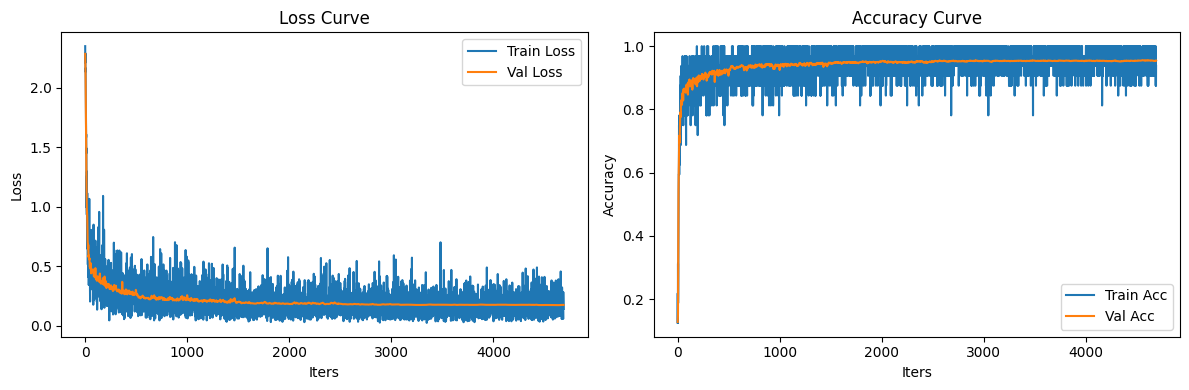

Best train set accuracy: 1.0
Best validation set accuracy: 0.954


In [5]:
train6 = train_model(dropout_p=[1.0])
print("Best train set accuracy:", max(train6.train_scores))
print("Best validation set accuracy:", train6.best_score)

### dropout_p=[0.7], $\lambda = 1e-4$

[Iter 200]
[Train] loss: 0.40303, score: 0.87500
[Dev] loss: 0.34610, score: 0.90120
[Iter 400]
[Train] loss: 0.16146, score: 0.96875
[Dev] loss: 0.30096, score: 0.91380
[Iter 600]
[Train] loss: 0.21961, score: 0.93750
[Dev] loss: 0.23694, score: 0.93640
[Iter 800]
[Train] loss: 0.18428, score: 0.96875
[Dev] loss: 0.24223, score: 0.92710
[Iter 1000]
[Train] loss: 0.09945, score: 0.96875
[Dev] loss: 0.22228, score: 0.93840
[Iter 1200]
[Train] loss: 0.39425, score: 0.87500
[Dev] loss: 0.20980, score: 0.94440
[Iter 1400]
[Train] loss: 0.18506, score: 0.96875
[Dev] loss: 0.21019, score: 0.94270
best accuracy updated: 0.00000 --> 0.94540
[Iter 1600]
[Train] loss: 0.62908, score: 0.81250
[Dev] loss: 0.19864, score: 0.94530
[Iter 1800]
[Train] loss: 0.16790, score: 0.93750
[Dev] loss: 0.19658, score: 0.94760
[Iter 2000]
[Train] loss: 0.32472, score: 0.87500
[Dev] loss: 0.20209, score: 0.94710
[Iter 2200]
[Train] loss: 0.23222, score: 0.93750
[Dev] loss: 0.19204, score: 0.94700
[Iter 2400]
[Tr

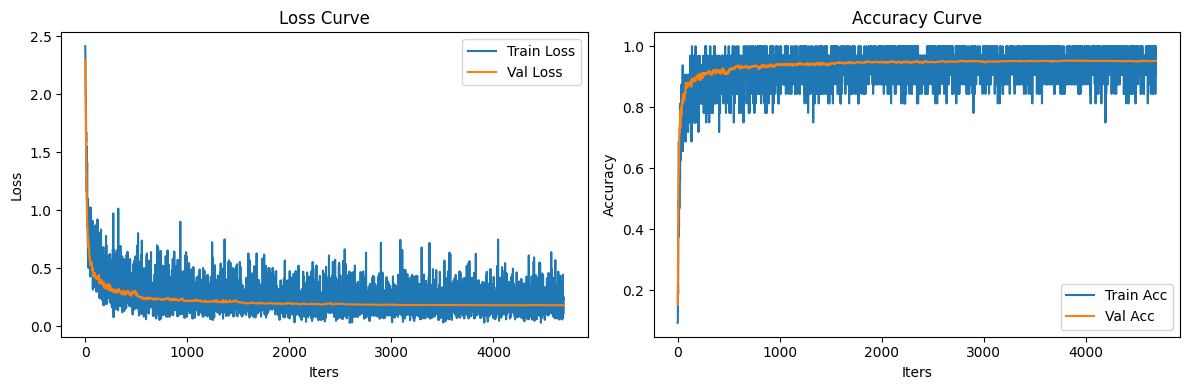

Best train set accuracy: 1.0
Best validation set accuracy: 0.9511


In [7]:
train6_1 = train_model(dropout_p=[0.7])
print("Best train set accuracy:", max(train6_1.train_scores))
print("Best validation set accuracy:", train6_1.best_score)

## 3. early stopping

In [2]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()



In [8]:
def train_model(nHidden = [128], lr=1.0, epochs=100,early_stop=8, initialize_method='He'):
    # 模型结构：输入层 + 隐藏层 + 输出层
    size_list = [train_imgs.shape[1]] + nHidden + [10]
    lambda_list = [1e-4] * (len(nHidden) + 1)  # 每层一个lambda
    
    # 初始化组件
    model = mynn.models.Model_MLP(size_list, 'ReLU', lambda_list, dropout_p=None, initialize_method=initialize_method)
    my_optimizer = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)
    scheduler = mynn.lr_scheduler.MultiStepLR(my_optimizer, milestones=[500, 1500, 2500, 3000], gamma=0.5)

    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    
    
    # 训练运行器
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=my_optimizer,
        metric=mynn.metric.accuracy,
        loss_fn=loss_fn,
        batch_size=32,
        scheduler=scheduler
    )
    
    # 执行训练
    trainer.train(
        train_set=[train_imgs, train_labs],
        dev_set=[valid_imgs, valid_labs],
        num_epochs=epochs,
        log_epochs=1,
        early_stop = early_stop,
        save_dir = f'./saved_models/Q3/earlystoptrue'
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 绘制训练和验证损失曲线
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epochs')  # x轴标签
    axes[0].set_ylabel('Loss')    # y轴标签
    axes[0].legend()

    # 绘制训练和验证准确度曲线
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Epochs')  # x轴标签
    axes[1].set_ylabel('Accuracy')  # y轴标签
    axes[1].legend()

    plt.tight_layout()  # 自动调整布局
    plt.show()
    
    return trainer

### early stop = True

best accuracy performence has been updated: 0.00000 --> 0.94480
Epoch 1/250:
[Train] loss: 0.28687, score: 0.91609
[Dev] loss: 0.20049, score: 0.94480
best accuracy performence has been updated: 0.94480 --> 0.95150
Epoch 2/250:
[Train] loss: 0.17798, score: 0.95341
[Dev] loss: 0.17999, score: 0.95150
best accuracy performence has been updated: 0.95150 --> 0.95370
Epoch 3/250:
[Train] loss: 0.16433, score: 0.95803
[Dev] loss: 0.17788, score: 0.95370
Epoch 4/250:
[Train] loss: 0.16239, score: 0.95923
[Dev] loss: 0.17733, score: 0.95290
Epoch 5/250:
[Train] loss: 0.16034, score: 0.95975
[Dev] loss: 0.17457, score: 0.95330
best accuracy performence has been updated: 0.95370 --> 0.95410
Epoch 6/250:
[Train] loss: 0.15889, score: 0.96043
[Dev] loss: 0.17199, score: 0.95410
best accuracy performence has been updated: 0.95410 --> 0.95520
Epoch 7/250:
[Train] loss: 0.15733, score: 0.96125
[Dev] loss: 0.17205, score: 0.95520
best accuracy performence has been updated: 0.95520 --> 0.95580
Epoch 8

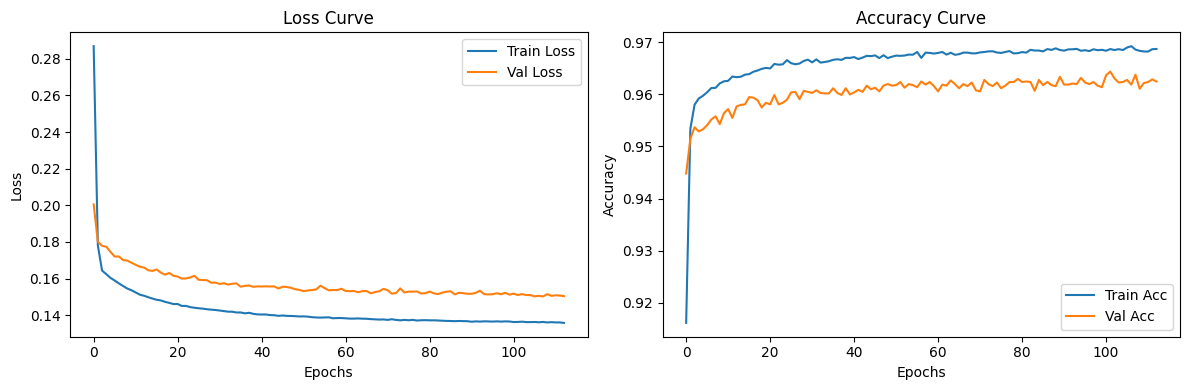

Best train set accuracy: 0.9692898272552783
Best validation set accuracy: 0.9644


In [9]:
trainer7 = train_model(epochs=250,early_stop=10)
print("Best train set accuracy:", max(trainer7.train_scores))
print("Best validation set accuracy:", trainer7.best_score)

### early stop = False

best accuracy performence has been updated: 0.00000 --> 0.94540
Epoch 1/250:
[Train] loss: 0.28035, score: 0.91895
[Dev] loss: 0.19845, score: 0.94540
best accuracy performence has been updated: 0.94540 --> 0.95380
Epoch 2/250:
[Train] loss: 0.17627, score: 0.95405
[Dev] loss: 0.17800, score: 0.95380
Epoch 3/250:
[Train] loss: 0.16401, score: 0.95893
[Dev] loss: 0.17649, score: 0.95350
best accuracy performence has been updated: 0.95380 --> 0.95500
Epoch 4/250:
[Train] loss: 0.16205, score: 0.95915
[Dev] loss: 0.17603, score: 0.95500
best accuracy performence has been updated: 0.95500 --> 0.95560
Epoch 5/250:
[Train] loss: 0.16030, score: 0.96025
[Dev] loss: 0.17357, score: 0.95560
Epoch 6/250:
[Train] loss: 0.15888, score: 0.96043
[Dev] loss: 0.17493, score: 0.95520
Epoch 7/250:
[Train] loss: 0.15751, score: 0.96107
[Dev] loss: 0.17165, score: 0.95510
best accuracy performence has been updated: 0.95560 --> 0.95640
Epoch 8/250:
[Train] loss: 0.15644, score: 0.96125
[Dev] loss: 0.17093,

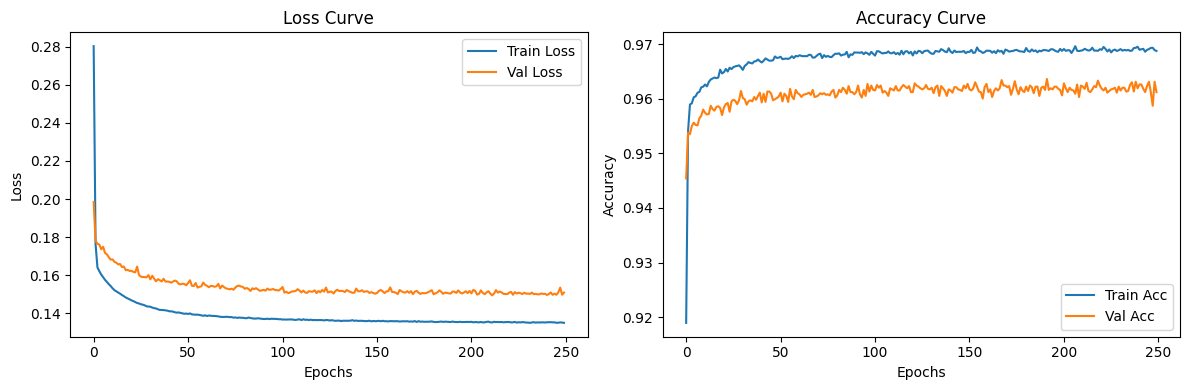

Best train set accuracy: 0.9696097248880359
Best validation set accuracy: 0.9636


In [4]:
trainer8 = train_model(epochs=250,early_stop=250)
print("Best train set accuracy:", max(trainer8.train_scores))
print("Best validation set accuracy:", trainer8.best_score)

从结果发现，早停可以防止过拟合， 相当于进行正则化。并且在测试集上，早停的模型的Accuracy为0.9673，没早停的模型的Accuracy为0.9663，显然，早停的模型的准确率更高。